# Member 1 — Handling Missing Data

**Technique:** Detect and handle missing or unreadable images before modelling.

## Why this dataset needs it
The basil dataset is organised as image folders, not a tidy CSV. “Missing data” here means:
- expected files listed for a region folder are absent
- files exist but **fail to decode** (corrupt / unsupported)
- an entire labelled folder is empty

Without this step, training would silently drop samples or crash mid-pipeline.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve Group_Deliverable root whether cwd is notebooks/ or deliverable root
HERE = Path.cwd().resolve()
ROOT = None
for p in (HERE, *HERE.parents):
    if (p / "src" / "preprocess_utils.py").exists():
        ROOT = p
        break
    if (p / "Group_Deliverable" / "src" / "preprocess_utils.py").exists():
        ROOT = p / "Group_Deliverable"
        break
if ROOT is None:
    raise FileNotFoundError("Run from progress/Group_Deliverable or its notebooks/ folder.")

sys.path.insert(0, str(ROOT / "src"))
from preprocess_utils import (
    SEED, SOURCE_URL, DOI, FOLDERS, CLASSES, paths,
    inventory_table, discover_images, audit_images,
    remove_exact_duplicates, iqr_mask, extract_feature_matrix, read_rgb,
    stratified_sample, draw_process_flow,
)

P = paths(ROOT)
RAW, VIZ, OUT, LOGS = P["raw"], P["viz"], P["outputs"], P["logs"]
for d in (VIZ, OUT, LOGS):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(SEED)
PIPELINE_STEPS = [
    "1 Missing\ndata",
    "2 Categorical\nencoding",
    "3 Outlier /\nduplicate",
    "4 Feature\nengineering",
    "5 Scaling",
    "6 SelectKBest\n+ PCA",
]
print("Deliverable root:", ROOT)
print("Raw data:", RAW)
print("Dataset:", SOURCE_URL, "| DOI:", DOI)


Deliverable root: D:\SLIIT\projectr\Dataset_Train\progress\Group_Deliverable
Raw data: D:\SLIIT\projectr\Dataset_Train\progress\Group_Deliverable\data\raw
Dataset: https://ieee-dataport.org/open-access/leaves-indias-most-famous-basil-plant-leaves-quality-dataset | DOI: 10.21227/a4f6-4413


## 0. Process diagram — where this step sits in the pipeline


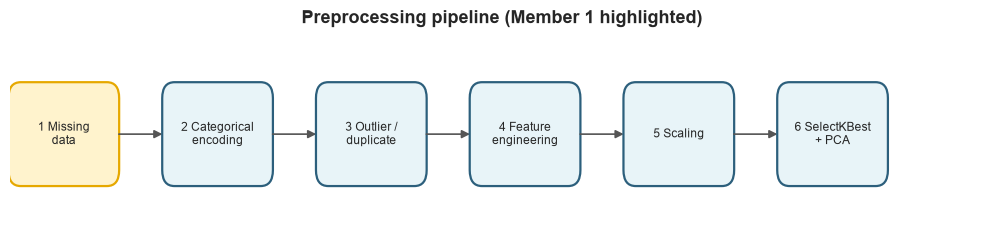

In [2]:
fig, _ = draw_process_flow(
    PIPELINE_STEPS,
    title="Preprocessing pipeline (Member 1 highlighted)",
    highlight=0,
)
fig.savefig(VIZ / "m1_process_flow.png", dpi=150, bbox_inches="tight")
plt.show()


## 1. Inventory expected vs found images


In [3]:
inv = inventory_table(RAW)
display(inv)

missing_total = int(inv["missing_count"].sum())
print(f"Total missing vs expected file counts: {missing_total}")
print(f"Folders incomplete: {(~inv['complete']).sum()} / {len(inv)}")


,folder,label,region,expected,found,missing_count,extra_count,complete
0,Amravati_Region_Basil_Plant_Healthy,Healthy,Amravati,31,31,0,0,True
1,Nagpur_Region_Basil_Plant_Healthy,Healthy,Nagpur,473,473,0,0,True
2,Pune_Region_Basil_Plant_Healthy,Healthy,Pune,146,146,0,0,True
3,Basil_Plant_Unhealthy,Unhealthy,Unknown,481,481,0,0,True


Total missing vs expected file counts: 0
Folders incomplete: 0 / 4


## 2. Discover files and audit readability (treat failed reads as missing)


In [4]:
discovered = discover_images(RAW)
print("Discovered image files:", len(discovered))

valid, rejected = audit_images(RAW, discovered)
print("Readable images:", len(valid))
print("Rejected / unreadable:", len(rejected))
if len(rejected):
    display(rejected[["path", "reason"]].head(20))

# Persist cleaned inventory for the group pipeline
valid.to_csv(OUT / "m1_valid_image_index.csv", index=False)
rejected.to_csv(OUT / "m1_rejected_images.csv", index=False)
inv.to_csv(OUT / "m1_folder_inventory.csv", index=False)

log = {
    "discovered": int(len(discovered)),
    "valid": int(len(valid)),
    "rejected": int(len(rejected)),
    "missing_vs_expected": missing_total,
}
(LOGS / "m1_missing_data.json").write_text(json.dumps(log, indent=2), encoding="utf-8")
print("Saved outputs under results/outputs and results/logs")


Discovered image files: 1131
Readable images: 1131
Rejected / unreadable: 0
Saved outputs under results/outputs and results/logs


## 3. EDA visualizations — class balance, completeness & comparisons


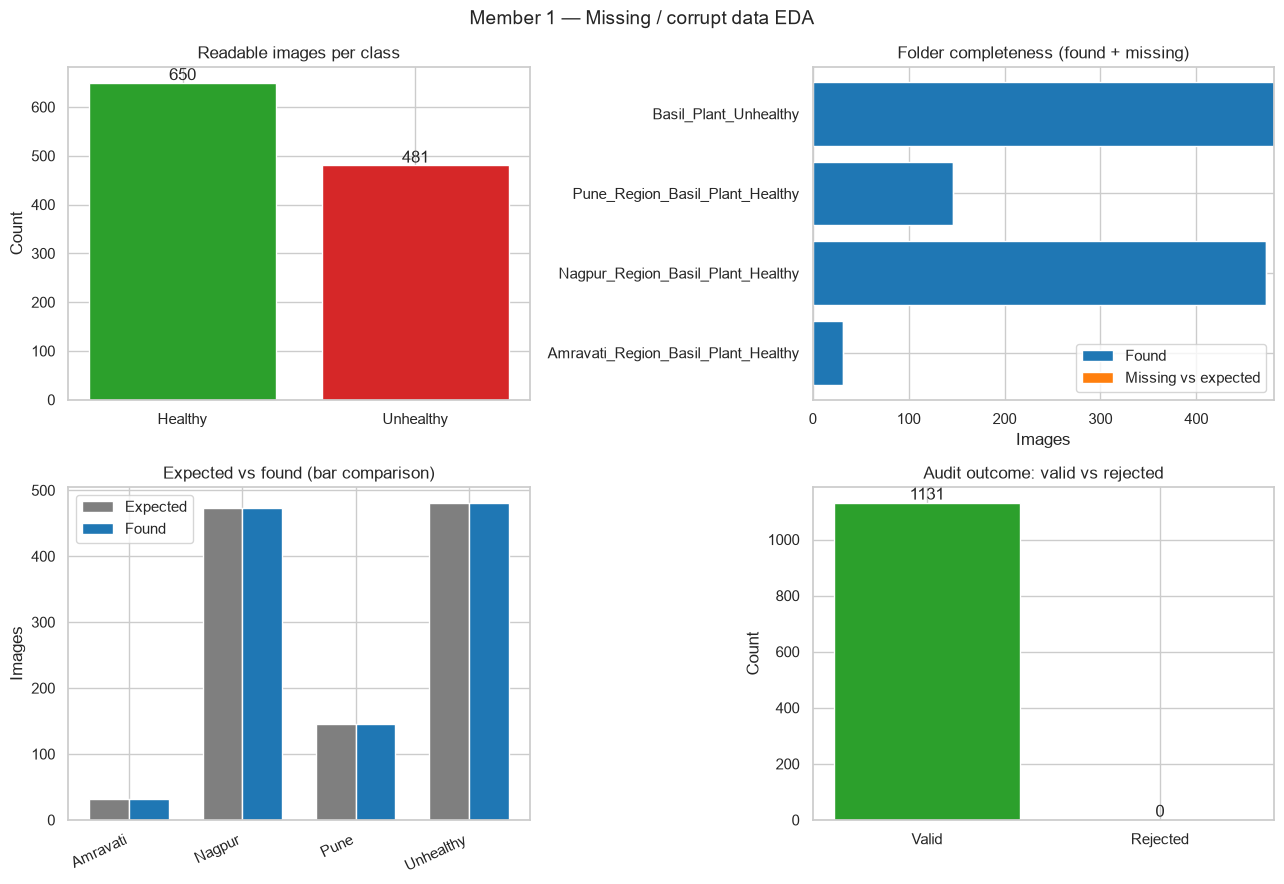

Interpretation: bars show whether both classes are present and whether any source folder is under-complete before later preprocessing.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Class counts among readable images
class_counts = valid["label"].value_counts().reindex(CLASSES).fillna(0)
bars = axes[0, 0].bar(class_counts.index, class_counts.values, color=["#2ca02c", "#d62728"])
axes[0, 0].set_title("Readable images per class")
axes[0, 0].set_ylabel("Count")
for b, v in zip(bars, class_counts.values):
    axes[0, 0].text(b.get_x() + b.get_width() / 2, v + 5, str(int(v)), ha="center")

# (2) Folder completeness stacked bars
axes[0, 1].barh(inv["folder"], inv["found"], color="#1f77b4", label="Found")
axes[0, 1].barh(inv["folder"], inv["missing_count"], left=inv["found"], color="#ff7f0e", label="Missing vs expected")
axes[0, 1].set_title("Folder completeness (found + missing)")
axes[0, 1].legend(loc="lower right")
axes[0, 1].set_xlabel("Images")

# (3) Expected vs found comparison (grouped bars)
x = np.arange(len(inv))
w = 0.35
axes[1, 0].bar(x - w / 2, inv["expected"], width=w, label="Expected", color="#7f7f7f")
axes[1, 0].bar(x + w / 2, inv["found"], width=w, label="Found", color="#1f77b4")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f.replace("_Region_Basil_Plant_Healthy", "").replace("Basil_Plant_", "") for f in inv["folder"]], rotation=25, ha="right")
axes[1, 0].set_title("Expected vs found (bar comparison)")
axes[1, 0].set_ylabel("Images")
axes[1, 0].legend()

# (4) Audit outcome pie / bar
audit_counts = pd.Series({"Valid": len(valid), "Rejected": len(rejected)})
axes[1, 1].bar(audit_counts.index, audit_counts.values, color=["#2ca02c", "#d62728"])
axes[1, 1].set_title("Audit outcome: valid vs rejected")
axes[1, 1].set_ylabel("Count")
for i, v in enumerate(audit_counts.values):
    axes[1, 1].text(i, v + max(5, 0.01 * max(audit_counts.values)), str(int(v)), ha="center")

fig.suptitle("Member 1 — Missing / corrupt data EDA", fontsize=14)
fig.tight_layout()
fig.savefig(VIZ / "m1_class_and_completeness.png", dpi=150, bbox_inches="tight")
plt.show()
print("Interpretation: bars show whether both classes are present and whether any source folder is under-complete before later preprocessing.")
